In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv(r'D:\Internship\Vehicle_Price_Prediction_working\data\dataset.csv')

In [3]:
df.head()

,name,description,make,model,year,price,engine,cylinders,fuel,mileage,transmission,trim,body,doors,exterior_color,interior_color,drivetrain
0,2024 Jeep Wagoneer Series II,"\n \n Heated Leather Seats, Nav Sy...",Jeep,Wagoneer,2024,74600.0,24V GDI DOHC Twin Turbo,6.0,Gasoline,10.0,8-Speed Automatic,Series II,SUV,4.0,White,Global Black,Four-wheel Drive
1,2024 Jeep Grand Cherokee Laredo,Al West is committed to offering every custome...,Jeep,Grand Cherokee,2024,50170.0,OHV,6.0,Gasoline,1.0,8-Speed Automatic,Laredo,SUV,4.0,Metallic,Global Black,Four-wheel Drive
2,2024 GMC Yukon XL Denali,NaN,GMC,Yukon XL,2024,96410.0,"6.2L V-8 gasoline direct injection, variable v...",8.0,Gasoline,0.0,Automatic,Denali,SUV,4.0,Summit White,Teak/Light Shale,Four-wheel Drive
3,2023 Dodge Durango Pursuit,White Knuckle Clearcoat 2023 Dodge Durango Pur...,Dodge,Durango,2023,46835.0,16V MPFI OHV,8.0,Gasoline,32.0,8-Speed Automatic,Pursuit,SUV,4.0,White Knuckle Clearcoat,Black,All-wheel Drive
4,2024 RAM 3500 Laramie,\n \n 2024 Ram 3500 Laramie Billet...,RAM,3500,2024,81663.0,24V DDI OHV Turbo Diesel,6.0,Diesel,10.0,6-Speed Automatic,Laramie,Pickup Truck,4.0,Silver,Black,Four-wheel Drive


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   name            1002 non-null   object 
 1   description     946 non-null    object 
 2   make            1002 non-null   object 
 3   model           1002 non-null   object 
 4   year            1002 non-null   int64  
 5   price           979 non-null    float64
 6   engine          1000 non-null   object 
 7   cylinders       897 non-null    float64
 8   fuel            995 non-null    object 
 9   mileage         968 non-null    float64
 10  transmission    1000 non-null   object 
 11  trim            1001 non-null   object 
 12  body            999 non-null    object 
 13  doors           995 non-null    float64
 14  exterior_color  997 non-null    object 
 15  interior_color  964 non-null    object 
 16  drivetrain      1002 non-null   object 
dtypes: float64(4), int64(1), object(1

In [5]:
df.describe()

,year,price,cylinders,mileage,doors
count,1002.000000,979.000000,897.000000,968.000000,995.000000
mean,2023.916168,50202.985700,4.975474,69.033058,3.943719
std,0.298109,18700.392062,1.392526,507.435745,0.274409
min,2023.000000,0.000000,0.000000,0.000000,2.000000
25%,2024.000000,36600.000000,4.000000,4.000000,4.000000
50%,2024.000000,47165.000000,4.000000,8.000000,4.000000
75%,2024.000000,58919.500000,6.000000,13.000000,4.000000
max,2025.000000,195895.000000,8.000000,9711.000000,5.000000


## UNIVARIATE ANALYSIS

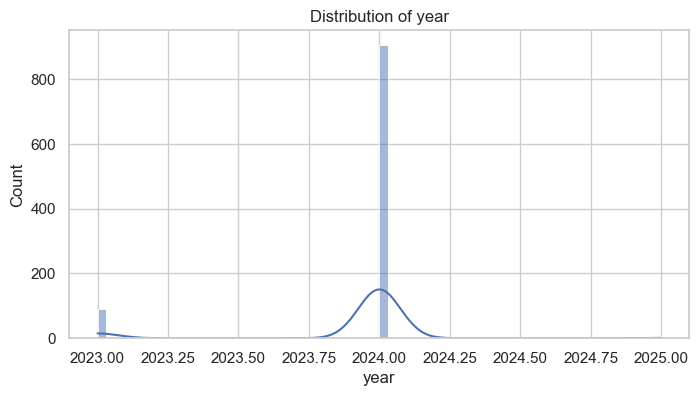

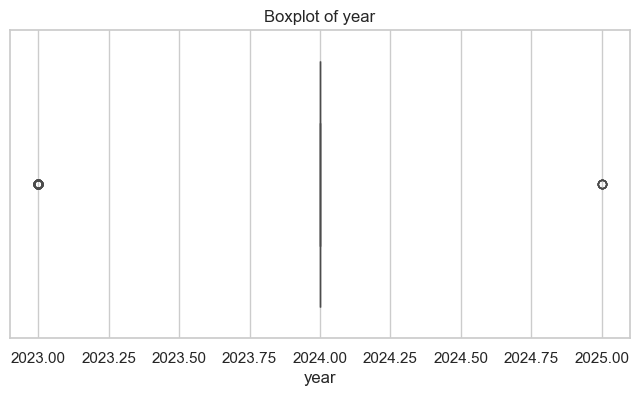

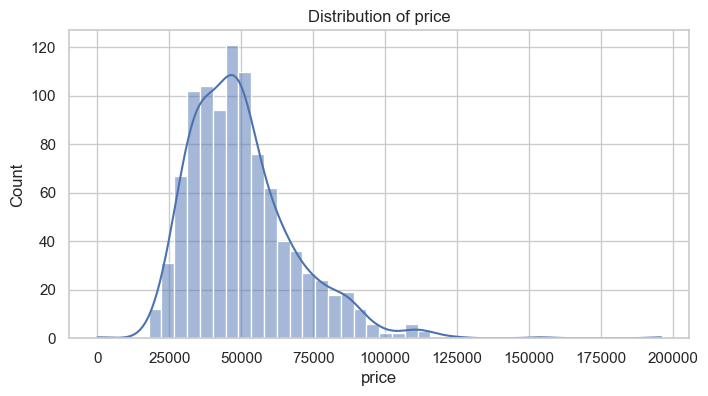

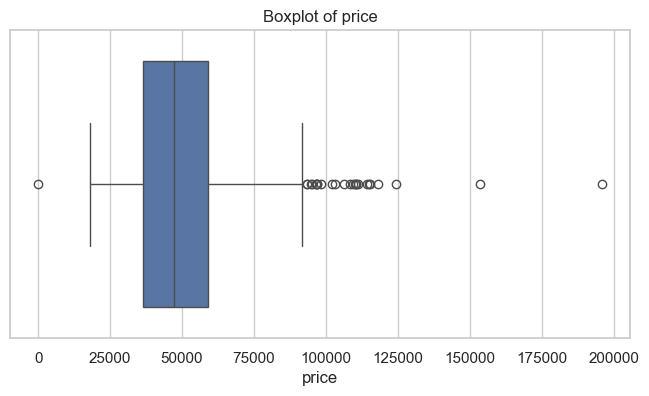

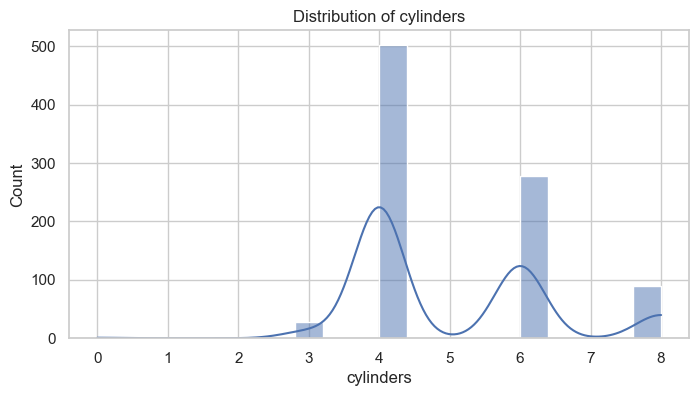

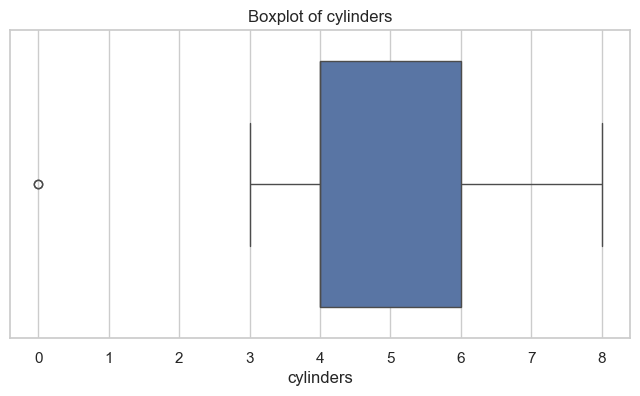

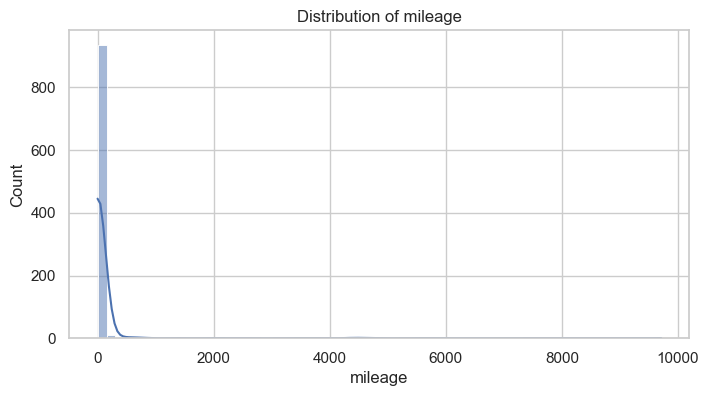

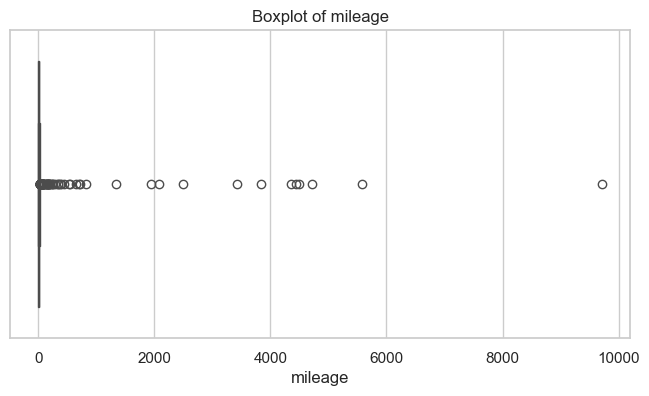

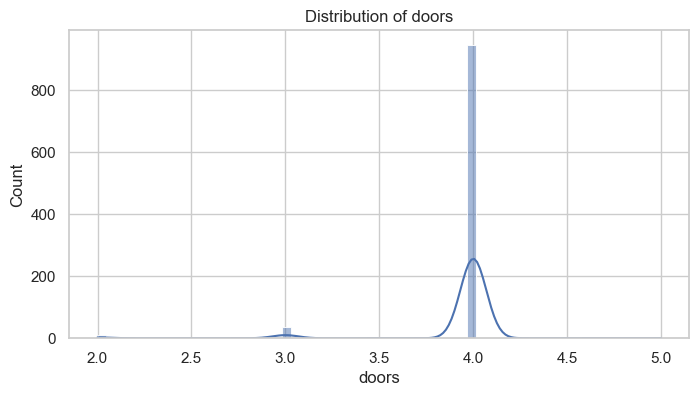

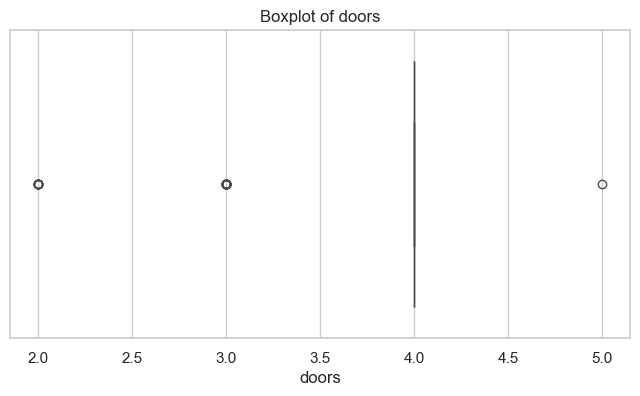

In [6]:
num_cols = ['year', 'price', 'cylinders', 'mileage', 'doors']

for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

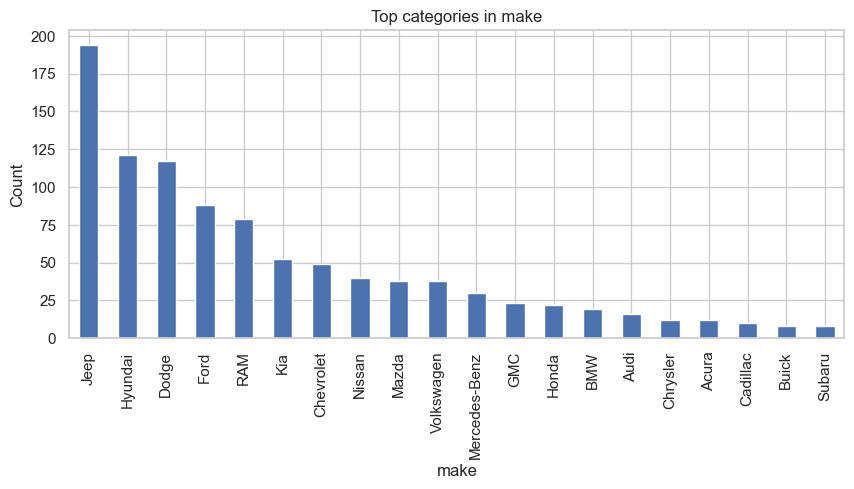

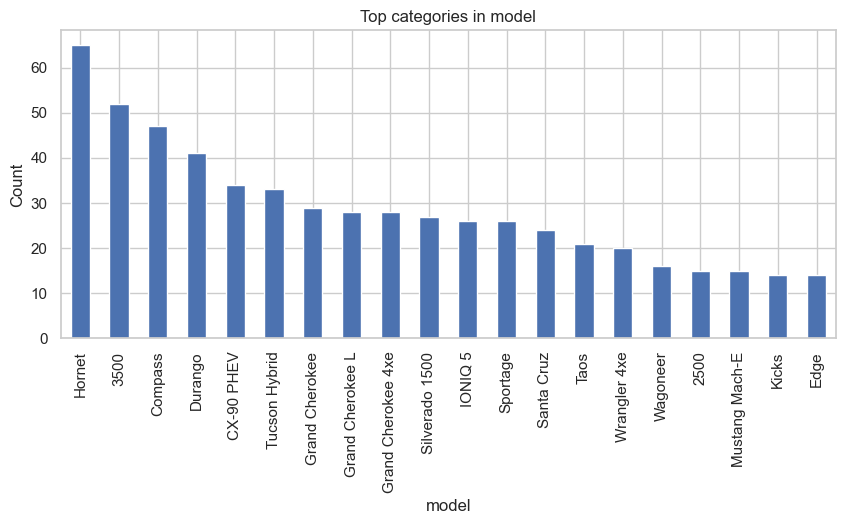

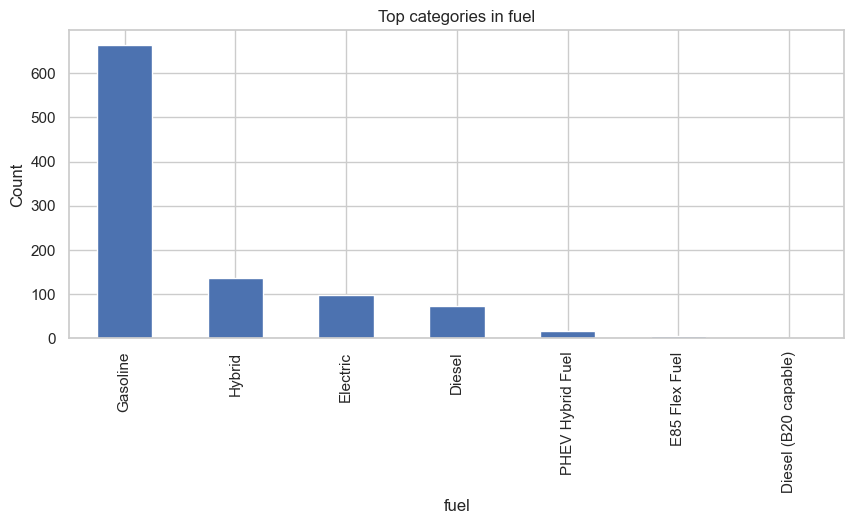

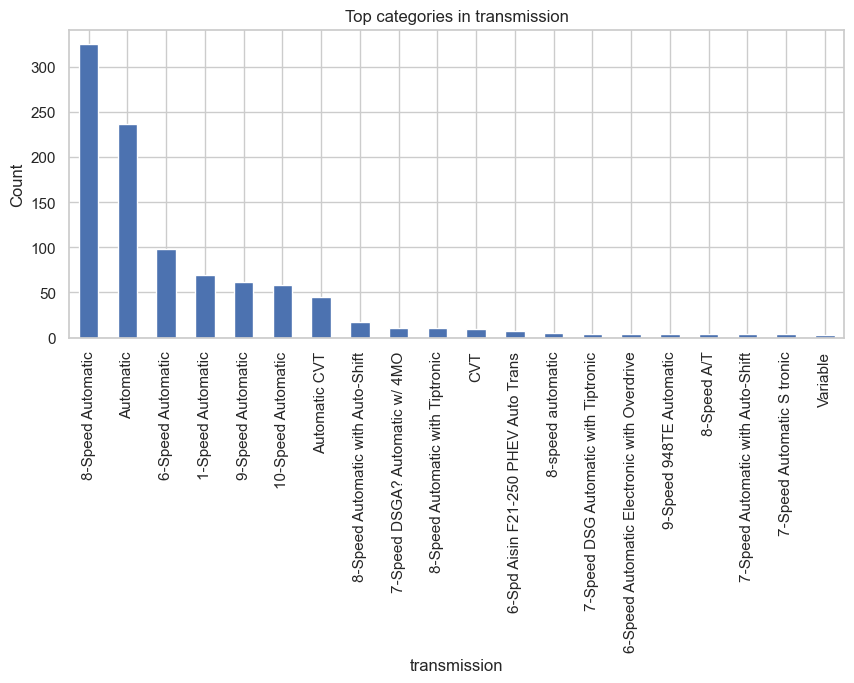

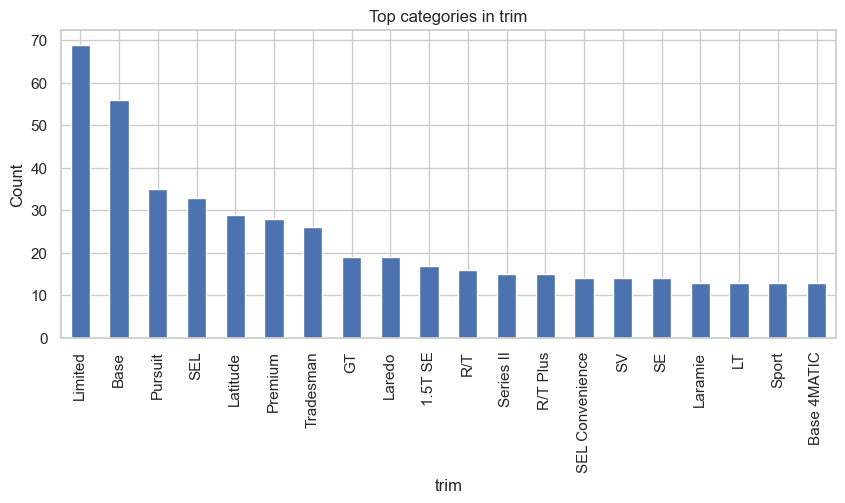

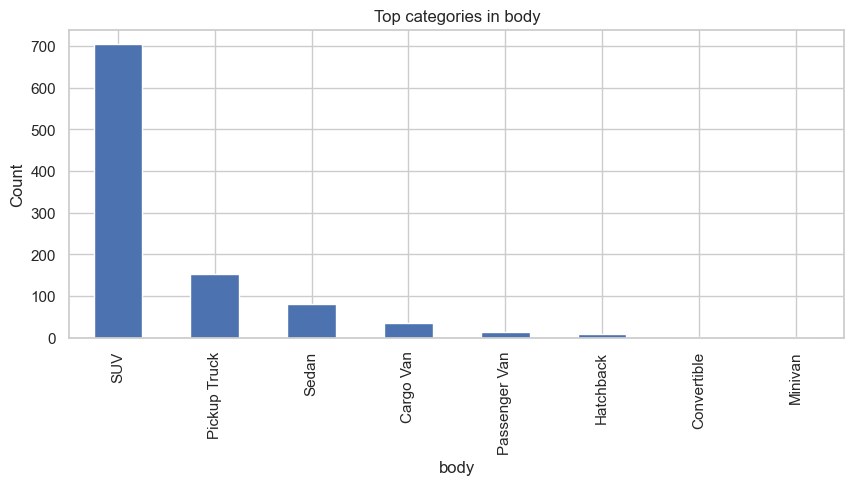

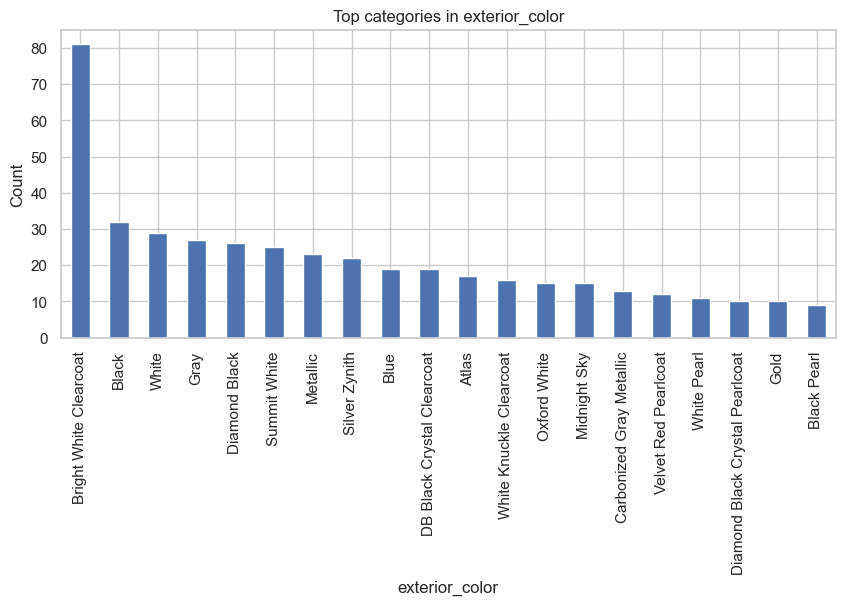

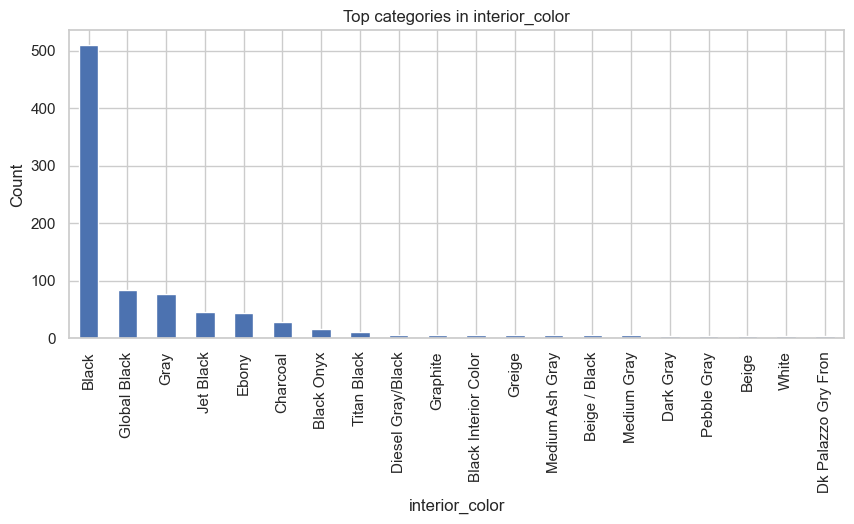

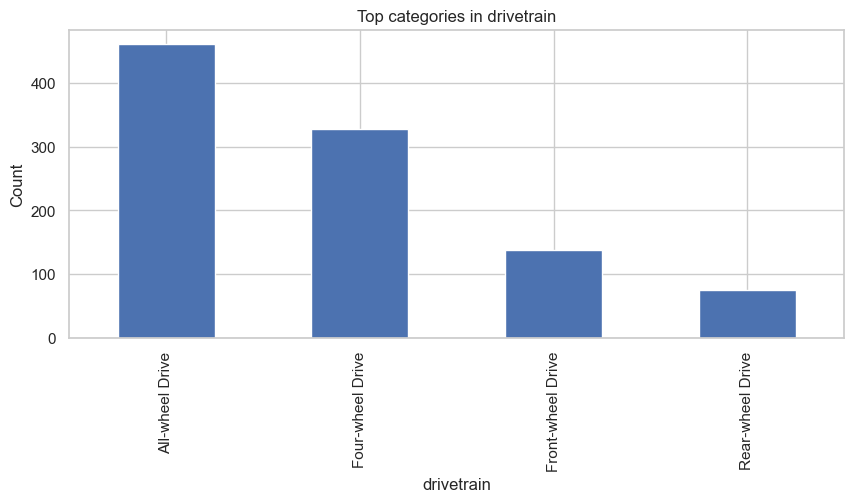

In [7]:
cat_cols = ['make','model','fuel','transmission','trim','body',
            'exterior_color','interior_color','drivetrain']

for col in cat_cols:
    plt.figure(figsize=(10,4))
    df[col].value_counts().head(20).plot(kind='bar')
    plt.title(f"Top categories in {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


## BIVARIATE ANALYSIS

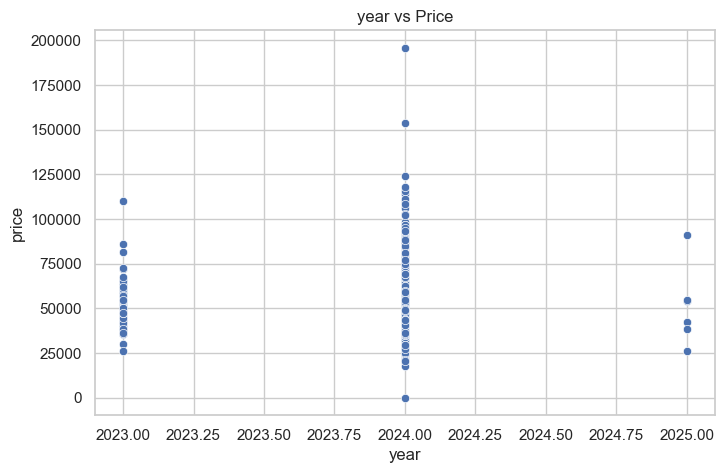

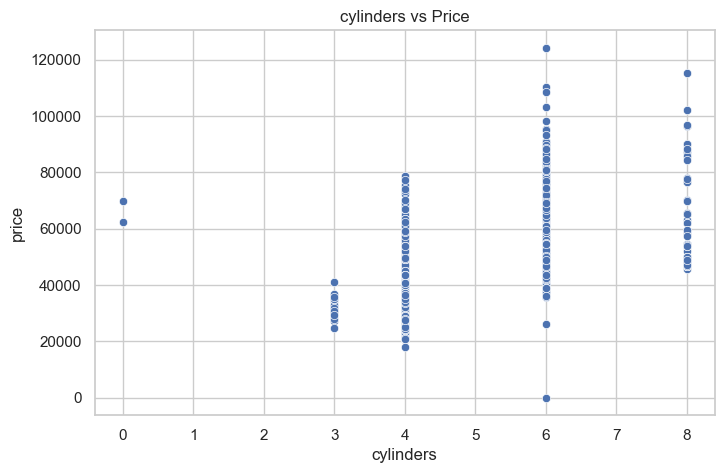

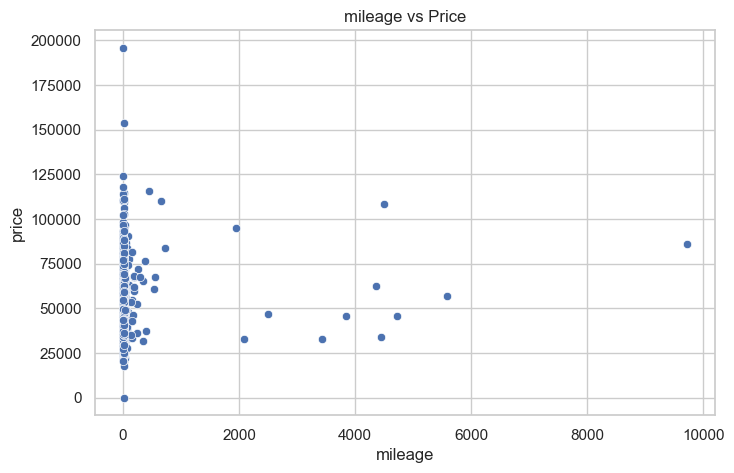

In [8]:
rel_cols = ['year', 'cylinders', 'mileage']

for col in rel_cols:
    plt.figure(figsize=(8,5))
    sns.scatterplot(x=df[col], y=df['price'])
    plt.title(f"{col} vs Price")
    plt.show()


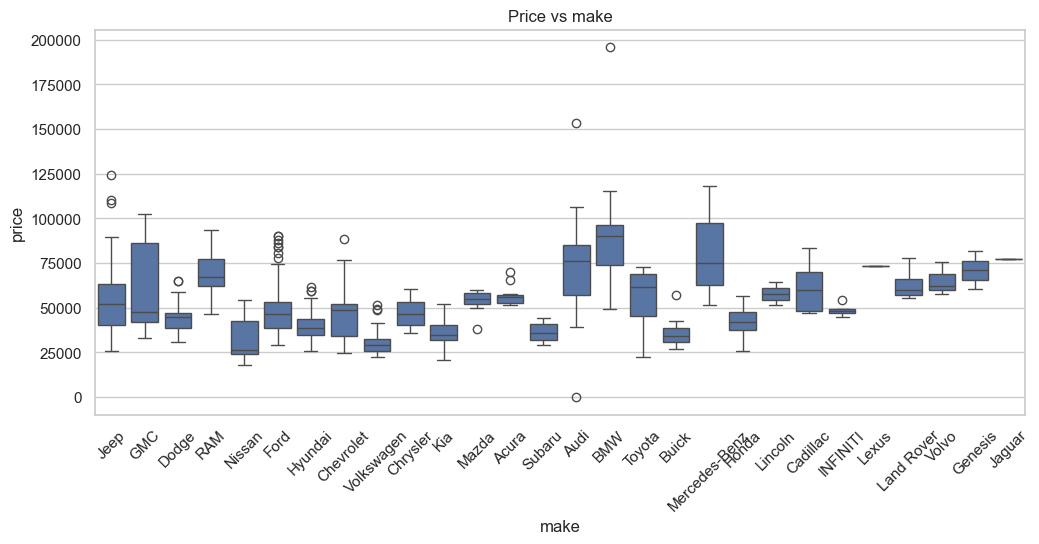

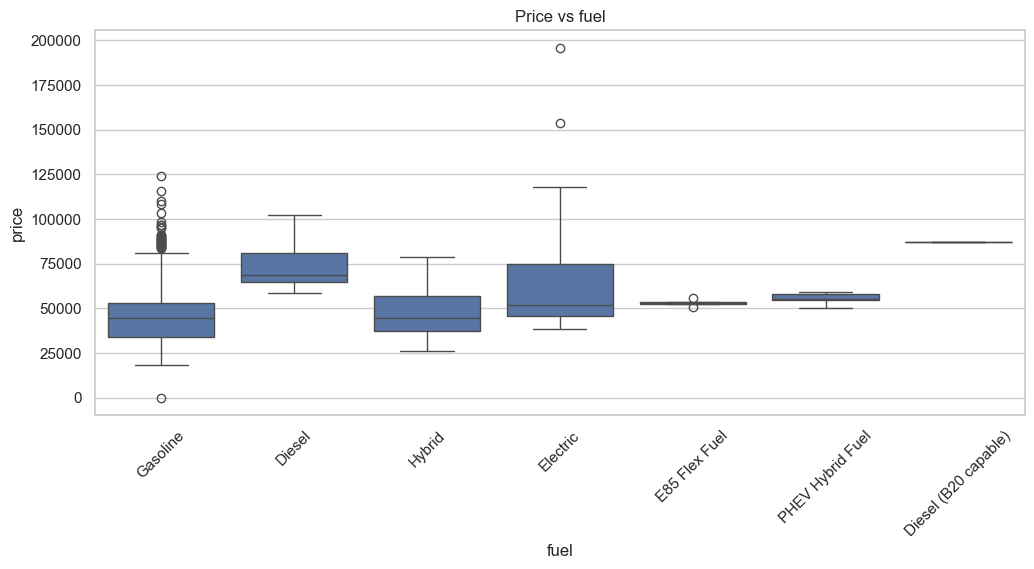

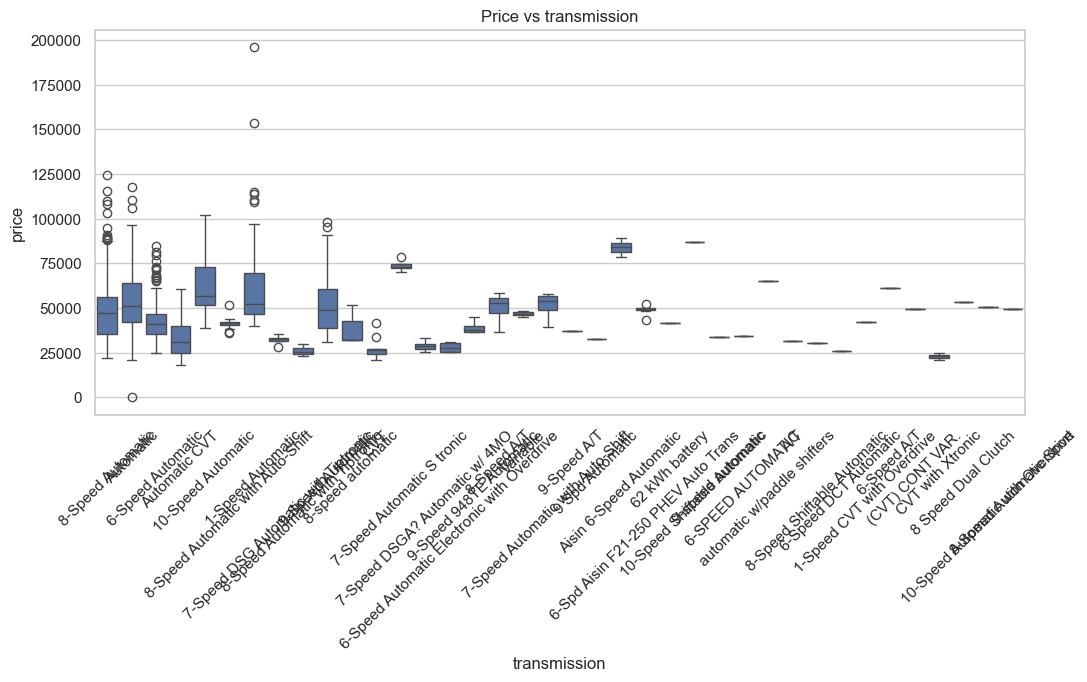

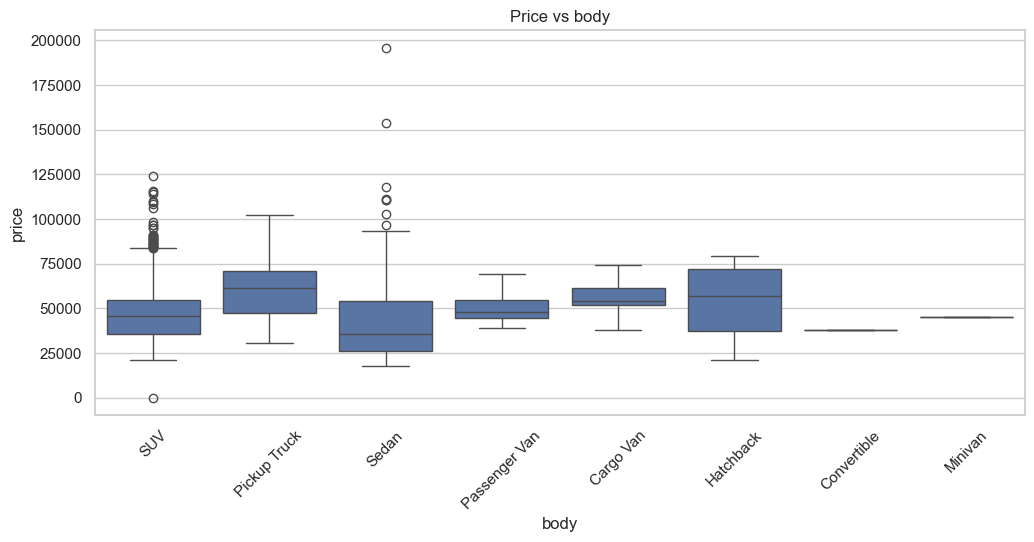

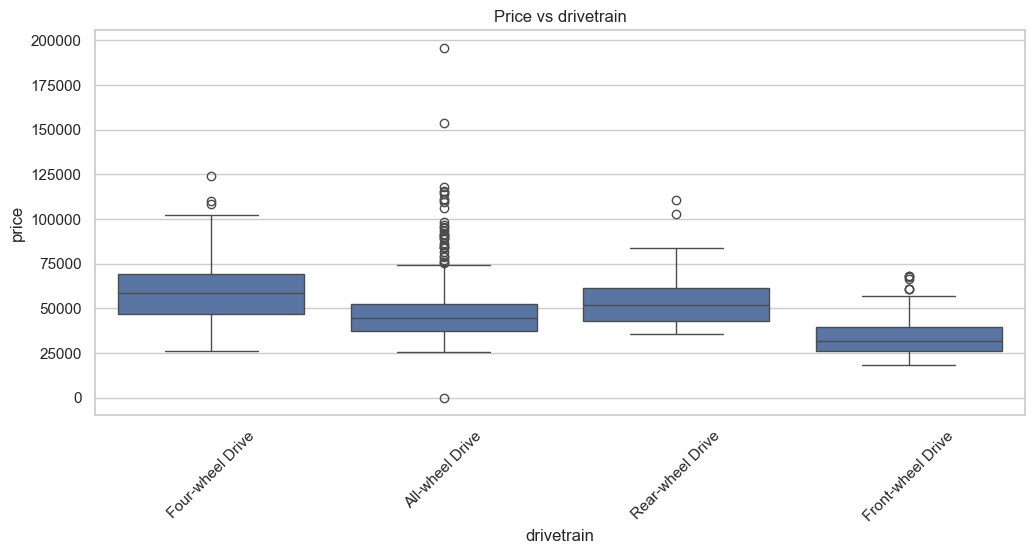

In [9]:
cat_for_price = ['make','fuel','transmission','body','drivetrain']

for col in cat_for_price:
    plt.figure(figsize=(12,5))
    sns.boxplot(x=df[col], y=df['price'])
    plt.xticks(rotation=45)
    plt.title(f"Price vs {col}")
    plt.show()


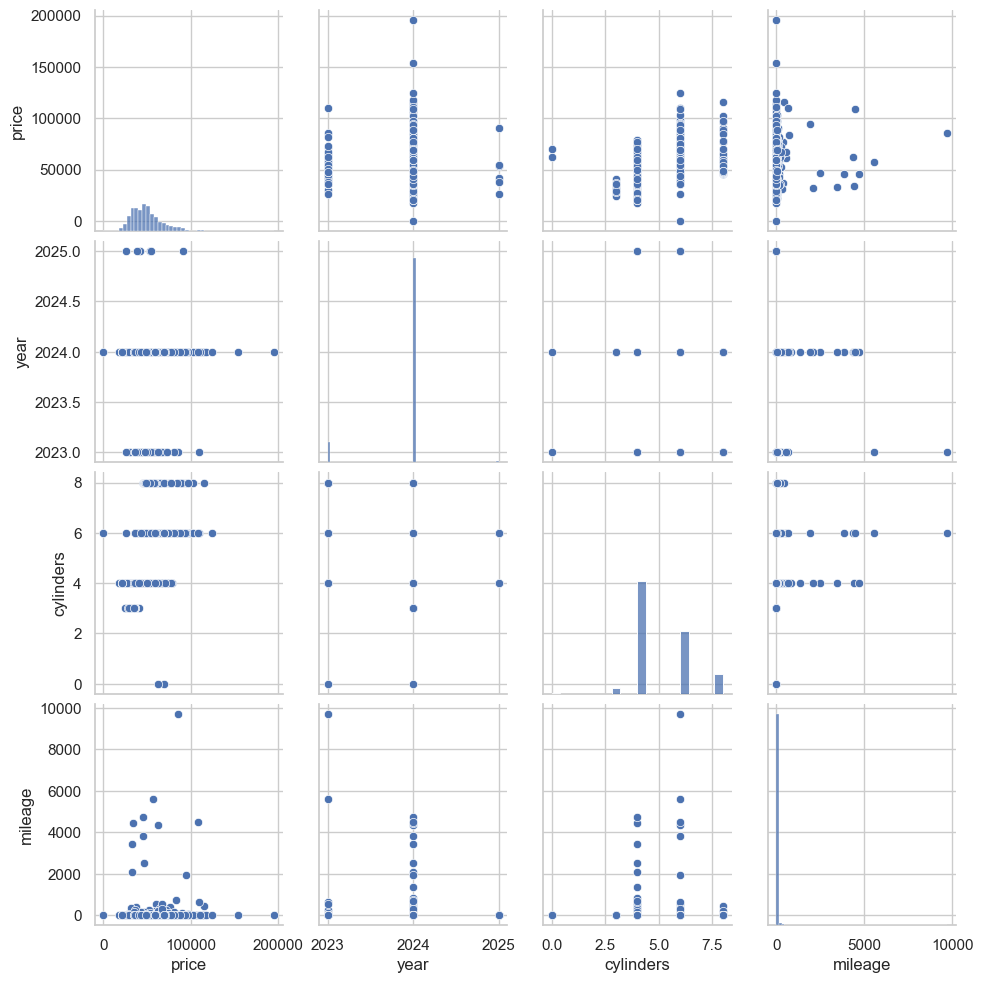

In [10]:
sns.pairplot(df[['price','year','cylinders','mileage']])
plt.show()


## MULTIVARIATE ANALYSIS

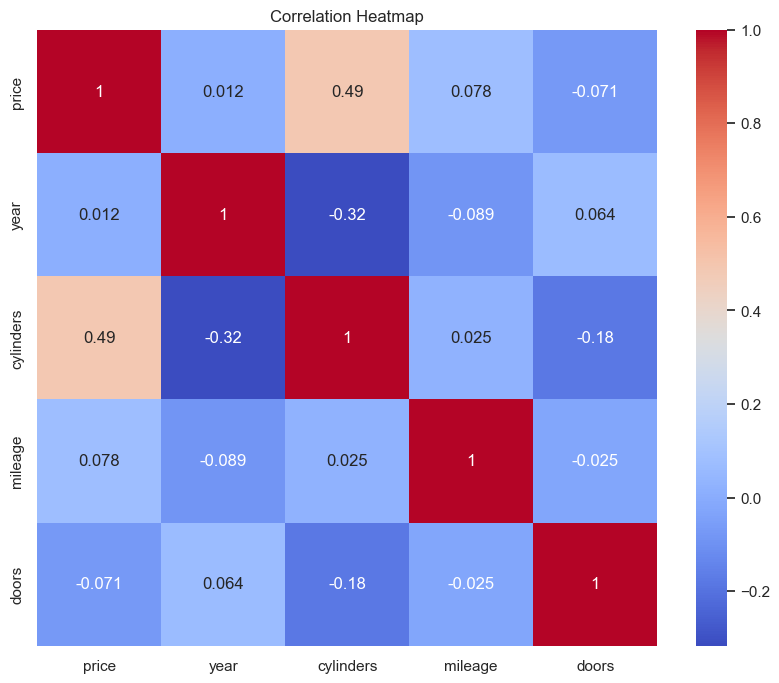

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df[['price','year','cylinders','mileage','doors']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


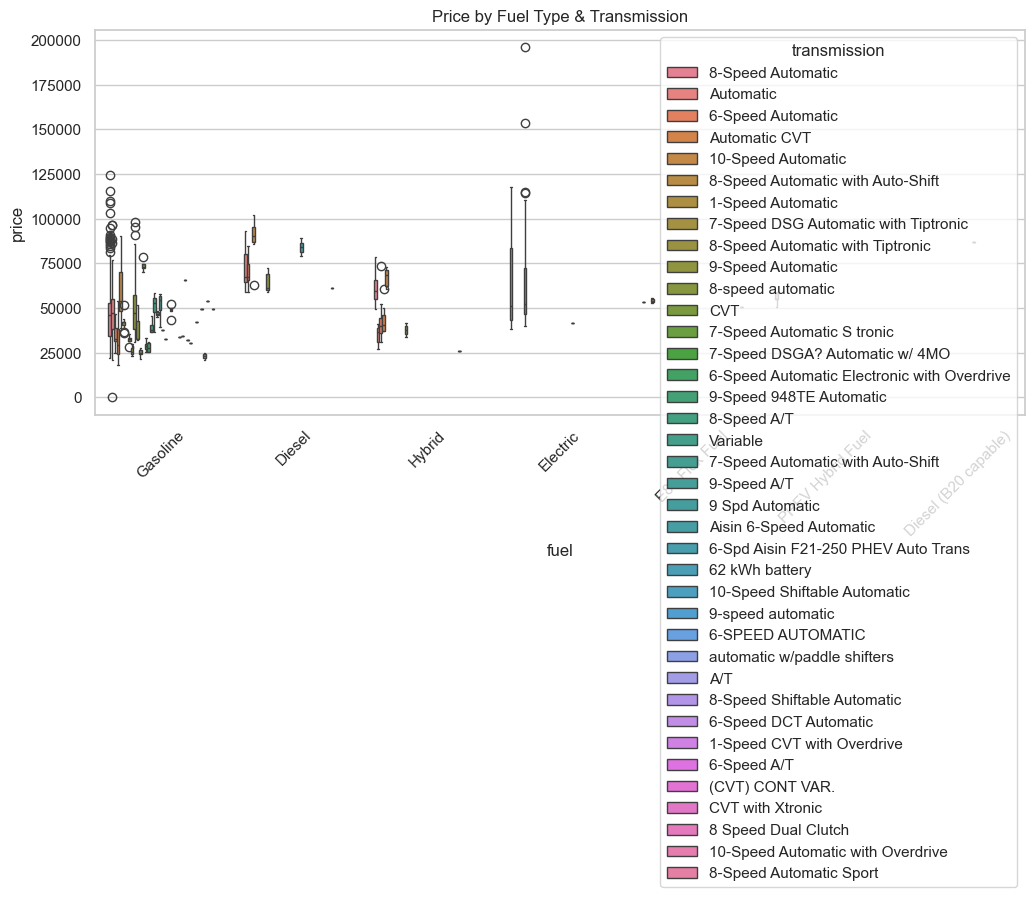

In [12]:
plt.figure(figsize=(12,5))
sns.boxplot(x='fuel', y='price', hue='transmission', data=df)
plt.title("Price by Fuel Type & Transmission")
plt.xticks(rotation=45)
plt.show()

In [19]:
pivot = pd.pivot_table(df, values='price',
                       index='make',
                       columns='fuel',
                       aggfunc='mean')

In [16]:
print(pivot)

fuel                 Diesel  Diesel (B20 capable)  E85 Flex Fuel  \
make                                                               
Acura                   NaN                   NaN            NaN   
Audi                    NaN                   NaN            NaN   
BMW                     NaN                   NaN            NaN   
Buick                   NaN                   NaN            NaN   
Cadillac                NaN                   NaN            NaN   
Chevrolet      64307.500000                   NaN            NaN   
Chrysler                NaN                   NaN            NaN   
Dodge                   NaN                   NaN            NaN   
Ford           89978.000000                   NaN        52979.2   
GMC            93803.000000               87075.0            NaN   
Genesis                 NaN                   NaN            NaN   
Honda                   NaN                   NaN            NaN   
Hyundai                 NaN                   Na

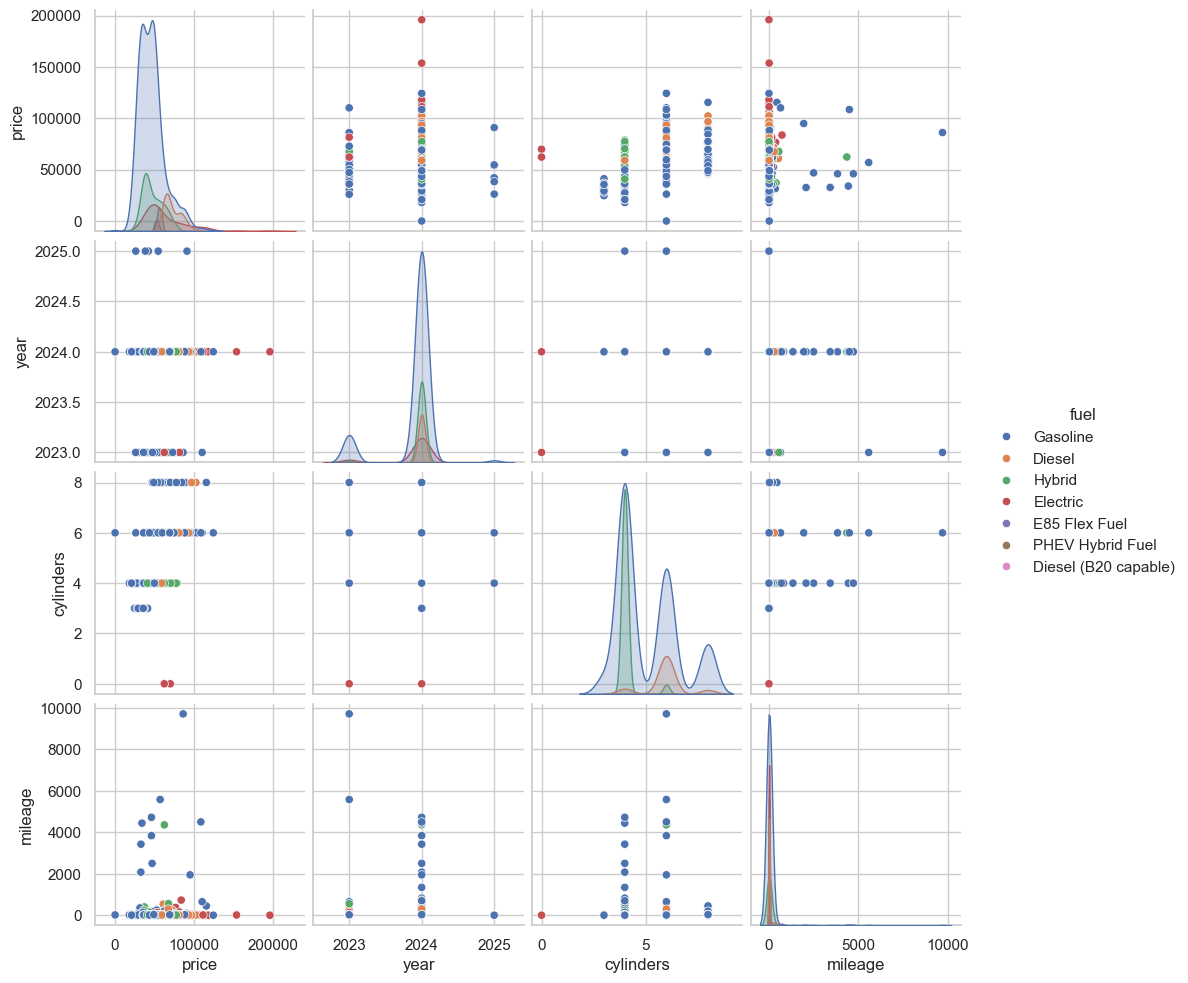

In [20]:
sns.pairplot(df[['price','year','cylinders','mileage','fuel']], 
             hue='fuel')
plt.show()